# Universidad Libre - Seccional Cali<br>Facultad de Ingeniería - Diplomado en Ciencia de Datos<br>(ↄ) Daniel Andres Barona Sandoval, 2026

# 04_modelo
Plantilla para el desarrollo del proyecto del diplomado de Ciencia de Datos, aplicando buenas prácticas.

---

Este cuaderno representa la culminación del proceso, donde aplicamos técnicas de machine learning para crear modelos predictivos o descriptivos basados en los datos preparados.

**Propósito:** Desarrollar, entrenar y validar modelos de machine learning que respondan a los objetivos del proyecto.

**Tareas habituales:**
- Selección de características (feature selection)
- Ingeniería de características (feature engineering)
- División de datos en conjuntos de entrenamiento y prueba
- Selección y entrenamiento de modelos
- Optimización de hiperparámetros
- Validación cruzada
- Evaluación de métricas de rendimiento
- Documentación del proceso de modelado
- Guardado y versionado de modelos
- Análisis de importancia de características

In [82]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, warnings
import os
warnings.filterwarnings("ignore")
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tools.sm_exceptions import InterpolationWarning
from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats
import joblib
from pathlib import Path
import ipywidgets as widgets
from IPython.display import display

In [83]:
!pip install pmdarima

In [84]:
try:
    import pmdarima as pm
    from pmdarima.arima.utils import ndiffs, nsdiffs
    HAS_PMDARIMA = True
except ImportError:
    HAS_PMDARIMA = False
    print('pmdarima no instalado: se usara grid search propio')

In [4]:
!git clone https://github.com/daniel-barona/proyecto_ciencia_datos

Cloning into 'proyecto_ciencia_datos'...
remote: Enumerating objects: 458, done.
remote: Counting objects: 100% (138/138), done.
remote: Compressing objects: 100% (56/56), done.
remote: Total 458 (delta 120), reused 82 (delta 82), pack-reused 320 (from 1)
Receiving objects: 100% (458/458), 608.78 MiB | 31.88 MiB/s, done.
Resolving deltas: 100% (264/264), done.
Updating files: 100% (56/56), done.


In [5]:
folder_path = Path("/content/proyecto_ciencia_datos/data/trusted")
files = list(folder_path.glob("*.xlsx"))
print(f"Archivos encontrados: {len(files)}")
for file in files:
    print(file.name)

Archivos encontrados: 1
SIPSA_2013_2026_trusted.xlsx


# DISEÑO DEL ALGORITMO

**La idea del algoritmo es la siguiente:**

1. El usuario debe seleccinar el departamento que desee estudiar, (puede escoger los departamentos disponibles, bogota esta incluido en la lista por el datset y Colombia tambien va a estar disponible si el usuario desea hacer un estudio a nivel nacional)
2. Despues de escoger el departamento (excluyendo bogota y colombia) el usuario podra escoger entre de las ciudades de ese departamento que pertenecen y que tienen activo centros de venta mayorista para poductos alimentarios.
3. Una vez escogido se le debe mostrar los productos disponibles en la ciudad.
4. el usuario escoge el producto a investigar.
5. Alli se empieza a realizar la estadistica, la idea es hacer selecion de todas las soliitudes realizadas por el usuario y realizar un problema de serie de tiempo
- Opcion A: usar los promedios mensuales por año (solicitud del cliente)
- Opcion B: recoletar todos los datos obtenidos de la solicitud de usuario por año
6. Debe realizar el analisis, presentar las graficas, presentar promedio de mes mensual actual (hasta junio) y dar la probabilidad del precio del producto en la cuidad seleccionada.


In [6]:
trusted_dir = "/content/proyecto_ciencia_datos/data/trusted"
df = pd.read_excel(f"{trusted_dir}/SIPSA_2013_2026_trusted.xlsx")
df

,fecha,grupo,producto,mercado,departamento,codigo_departamento,municipio,codigo_municipio,precio_promedio_kg,circulacion
0,2013-01-01,carnes,alas de pollo con costillar,"barranquilla, barranquillita",atlantico,8,barranquilla,8001,3073.0,si
1,2013-01-01,carnes,alas de pollo con costillar,"bogota, d.c., frigorifico guadalupe","bogota, d.c.",11,"bogota, d.c.",11001,2560.0,si
2,2013-01-01,carnes,alas de pollo con costillar,"cartagena, bazurto",bolivar,13,cartagena de indias,13001,3429.0,si
3,2013-01-01,carnes,alas de pollo con costillar,"ibague, plaza la 21",tolima,73,ibague,73001,4307.0,si
4,2013-01-01,carnes,alas de pollo con costillar,"medellin, plaza minorista ""jose maria villa""",antioquia,5,medellin,5001,3717.0,si
...,...,...,...,...,...,...,...,...,...,...
749048,2026-06-01,frutas,manzana royal gala importada,"neiva, surabastos",huila,41,neiva,41001,8706.0,si
749049,2026-06-01,frutas,manzana royal gala importada,"monteria, mercado del sur",cordoba,23,monteria,23001,8573.0,si
749050,2026-06-01,frutas,manzana royal gala importada,"medellin, central mayorista de antioquia",antioquia,5,medellin,5001,7517.0,si
749051,2026-06-01,frutas,naranja valencia,"valledupar, mercabastos",cesar,20,valledupar,20001,2494.0,si


## Entrenar el Modelo

In [7]:
departamentos_2026 = sorted(
    df.loc[df["fecha"].dt.year == 2026, "departamento"]
      .dropna()
      .unique()
)
departamentos_2026

['antioquia',
 'arauca',
 'atlantico',
 'bogota, d.c.',
 'bolivar',
 'boyaca',
 'caldas',
 'caqueta',
 'casanare',
 'cauca',
 'cesar',
 'cordoba',
 'cundinamarca',
 'huila',
 'magdalena',
 'meta',
 'narino',
 'norte de santander',
 'quindio',
 'risaralda',
 'santander',
 'sucre',
 'tolima',
 'valle del cauca']

In [8]:
departamentos = ['colombia'] + departamentos_2026

In [9]:
dropdown_departamento = widgets.Dropdown(
    options=departamentos,
    description='Departamento:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='400px')
)
display(dropdown_departamento)

Dropdown(description='Departamento:', layout=Layout(width='400px'), options=('colombia', 'antioquia', 'arauca'…

In [12]:
departamento = dropdown_departamento.value
print("Departamento seleccionado:", departamento)

Departamento seleccionado: valle del cauca


In [13]:
if departamento.lower() not in ['colombia', 'bogota, d.c.']:
    municipios = sorted(
        df[
            (df["departamento"] == departamento) &
            (df["fecha"].dt.year == 2026)
        ]["municipio"]
        .dropna()
        .unique()
        .tolist()
    )

    dropdown_municipio = widgets.Dropdown(
        options=municipios,
        description='Municipio:',
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='400px')
    )

    display(dropdown_municipio)

else:
    print("No es necesario seleccionar un municipio.")

Dropdown(description='Municipio:', layout=Layout(width='400px'), options=('buenaventura', 'cali', 'cartago', '…

In [14]:
if departamento.lower() not in ['colombia', 'bogota, d.c.']:
    municipio = dropdown_municipio.value
    print("Municipio seleccionado:", municipio)

Municipio seleccionado: cali


In [15]:
if departamento.lower() == 'colombia':
    # Modo nacional: no se elige un mercado especifico, se promediara
    # el producto seleccionado en TODOS los mercados del pais.
    print("Modo nacional seleccionado: el producto se promediara entre todos los mercados del pais.")

elif departamento.lower() == 'bogota, d.c.':

    mercados = sorted(
        df[
            (df["departamento"] == departamento) &
            (df["fecha"].dt.year == 2026)
        ]["mercado"]
        .dropna()
        .unique()
        .tolist()
    )

    dropdown_mercado = widgets.Dropdown(
        options=mercados,
        description='Mercado:',
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='400px')
    )
    display(dropdown_mercado)

else:

    municipio = dropdown_municipio.value

    mercados = sorted(
        df[
            (df["municipio"] == municipio) &
            (df["fecha"].dt.year == 2026)
        ]["mercado"]
        .dropna()
        .unique()
        .tolist()
    )

    dropdown_mercado = widgets.Dropdown(
        options=mercados,
        description='Mercado:',
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='400px')
    )
    display(dropdown_mercado)

Dropdown(description='Mercado:', layout=Layout(width='400px'), options=('cali, cavasa', 'cali, galeria alameda…

In [16]:
if departamento.lower() == 'colombia':
    mercado = None
    print("Mercado: N/A (se calculará el promedio nacional)")
else:
    mercado = dropdown_mercado.value
    print("Mercado seleccionado:", mercado)

Mercado seleccionado: cali, santa elena


In [17]:
if mercado is None:
    # Nacional: productos disponibles en cualquier mercado del pais
    productos = sorted(
        df[df["fecha"].dt.year == 2026]["producto"]
        .dropna()
        .unique()
        .tolist()
    )
else:
    productos = sorted(
        df[
            (df["mercado"] == mercado) &
            (df["fecha"].dt.year == 2026)
        ]["producto"]
        .dropna()
        .unique()
        .tolist()
    )

dropdown_producto = widgets.Dropdown(
    options=productos,
    description='Producto:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='400px')
)
display(dropdown_producto)

Dropdown(description='Producto:', layout=Layout(width='400px'), options=('aceite vegetal mezcla', 'aguacate ch…

In [18]:
producto = dropdown_producto.value
print("Producto seleccionado:", producto)

Producto seleccionado: banano criollo


## Inicio del Modelo - Hacer Pruebas

##Variables predefinidas

In [85]:
M = 12            # periodicidad estacional (12 = mensual con ciclo anual)
TEST_SIZE = None   # None = se calcula automaticamente; o forzar un numero de meses, ej. 12
H_FUTURO = 12       # meses a pronosticar hacia el futuro con el modelo ganador

# Fase 1: creacion de la serie

In [86]:
# Si mercado es None (modo nacional / departamento = 'colombia'), se  promedian los precios del producto entre TODOS los mercados del pais.
def preparar_serie(df, producto, mercado=None):
    base = df[df['producto'] == producto]
    if mercado is not None:
        base = base[base['mercado'] == mercado]

    serie = base[['fecha', 'precio_promedio_kg']].copy()
    serie = serie.sort_values('fecha')
    serie.set_index('fecha', inplace=True)
    serie.rename(columns={'precio_promedio_kg': 'precio'}, inplace=True)
    # Promedio de todos los registros de la misma fecha
    # (varios mercados/municipios reportando el mismo mes)
    serie = serie.groupby(serie.index).mean()
    # Frecuencia mensual + relleno de huecos
    serie = serie.asfreq('MS').interpolate('linear').ffill().bfill()
    return serie['precio']

y = preparar_serie(df, producto, mercado)
mercado_label = 'Colombia (promedio nacional)' if mercado is None else mercado
print(f'Serie construida ({mercado_label}): {len(y)} observaciones, '
      f'de {y.index[0].strftime("%Y-%m")} a {y.index[-1].strftime("%Y-%m")}')

display(y.round(2))

Serie construida (cali, santa elena): 162 observaciones, de 2013-01 a 2026-06


,precio
fecha,
2013-01-01,573.0
2013-02-01,579.0
2013-03-01,589.0
2013-04-01,580.0
2013-05-01,576.0
...,...
2026-02-01,1800.0
2026-03-01,1769.0
2026-04-01,1693.0


## Fase 1b — Verificación del tamaño de la serie
Antes de modelar, comprueba que la serie tenga suficientes observaciones. Reglas prácticas para SARIMA con estacionalidad mensual (m=12):

- **< 24 meses**: insuficiente — no se puede estimar componente estacional.
- **24–35 meses**: mínimo aceptable — modelo poco confiable, evita SARIMA (usa ARIMA no estacional).
- **36–47 meses**: aceptable — SARIMA viable pero con incertidumbre alta.
- **48–71 meses**: bueno — recomendado (≥ 4 ciclos estacionales).
- **≥ 72 meses**: óptimo (≥ 6 ciclos).

In [87]:
def fuerza_estacional(y, m=12):
    """Fs = max(0, 1 - Var(resid)/Var(resid+seasonal))  (Hyndman). >0.3 ~ estacionalidad util."""
    if len(y) < 2*m + 1:
        return np.nan
    try:
        res = STL(y, period=m, robust=True).fit()
    except Exception:
        return np.nan
    var_r  = np.nanvar(res.resid)
    var_rs = np.nanvar(res.resid + res.seasonal)
    return float(max(0.0, 1 - var_r/var_rs)) if var_rs > 0 else 0.0

def verificar_registros(y, m=12):
    n = int(y.dropna().shape[0])
    ciclos = n / m
    nivel = ('INSUFICIENTE' if n < 24 else 'MINIMO' if n < 36 else
             'ACEPTABLE' if n < 48 else 'BUENO' if n < 72 else 'OPTIMO')

    Fs = fuerza_estacional(y, m)
    ciclos_ok = n >= 3*m
    # FIX: la estacionalidad se usa solo si hay ciclos suficientes Y senal estacional real
    seasonal_ok = bool(ciclos_ok and np.isfinite(Fs) and Fs >= 0.30)
    seasonal_debil = bool(ciclos_ok and np.isfinite(Fs) and 0.15 <= Fs < 0.30)

    # presupuesto de parametros: ~1 por cada 10 observaciones
    presupuesto = max(2, n // 10)
    max_p = 3 if n >= 60 else 2 if n >= 36 else 1
    max_q = max_p
    max_P = 1 if seasonal_ok else 0
    max_Q = 1 if (seasonal_ok and n >= 4*m) else 0

    # horizonte de backtest: al menos 1 ciclo si alcanza, dejando train >= 3 ciclos
    h_bt = int(min(m, max(6, n // 5), max(3, n - max(3*m, 24))))

    info = dict(n=n, ciclos=round(ciclos,2), nivel=nivel, apto=n>=24, m=m,
                Fs=None if not np.isfinite(Fs) else round(Fs,3),
                seasonal_ok=seasonal_ok, seasonal_debil=seasonal_debil,
                max_p=max_p, max_q=max_q, max_P=max_P, max_Q=max_Q,
                presupuesto=presupuesto, h_bt=h_bt)

    print(f"Registros            : {n}")
    print(f"Ciclos (m={m})        : {ciclos:.2f}")
    print(f"Nivel                : {nivel}")
    print(f"Fuerza estacional Fs : {info['Fs']}  (>=0.30 usa SARIMA, <0.15 no aporta)")
    print(f"Componente estacional: {'SI' if seasonal_ok else 'NO -> ARIMA no estacional'}"
          + (' [debil]' if seasonal_debil else ''))
    print(f"Limites busqueda     : p<={max_p} q<={max_q} P<={max_P} Q<={max_Q} (max {presupuesto} params)")
    print(f"Horizonte backtest   : {h_bt} meses")
    if not info['apto']:
        print('ATENCION: serie insuficiente para modelar (<24).')
    return info
info = verificar_registros(y)

Registros            : 162
Ciclos (m=12)        : 13.50
Nivel                : OPTIMO
Fuerza estacional Fs : 0.082  (>=0.30 usa SARIMA, <0.15 no aporta)
Componente estacional: NO -> ARIMA no estacional
Limites busqueda     : p<=3 q<=3 P<=0 Q<=0 (max 16 params)
Horizonte backtest   : 12 meses


#Fase 3: EDA express y especifico

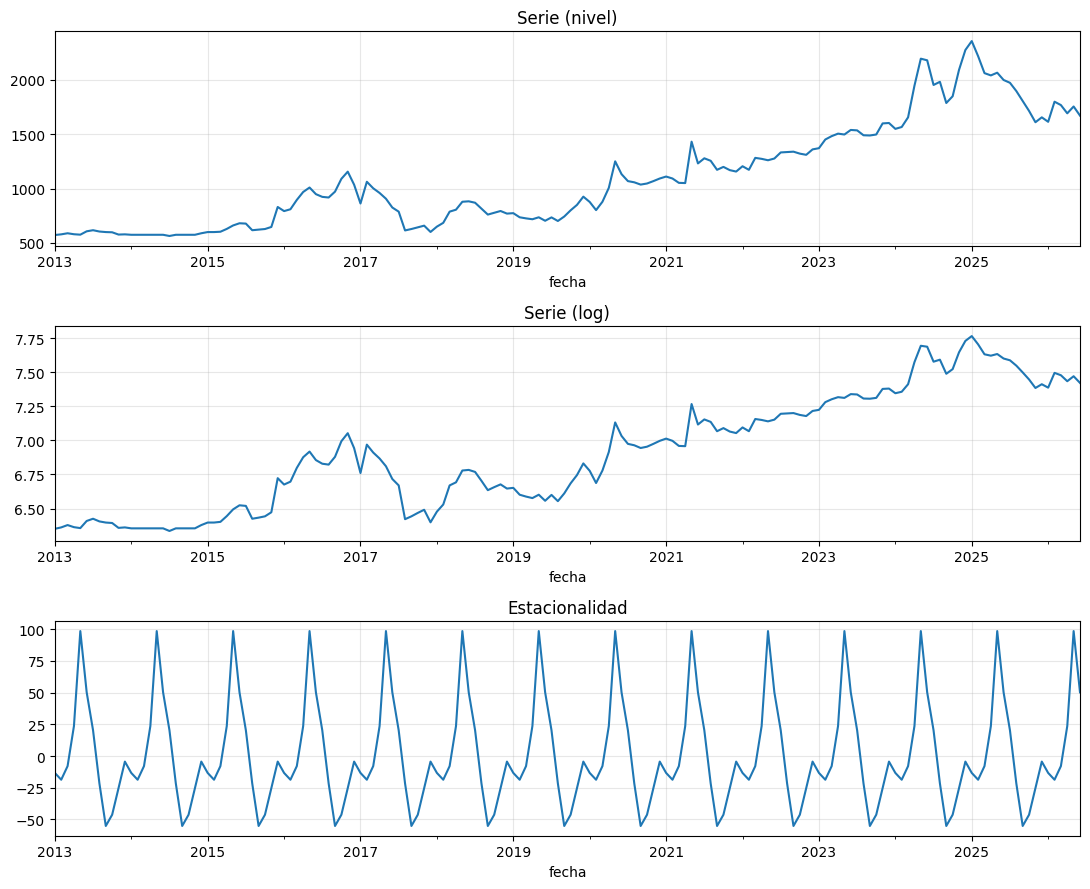

Amplitud estacional = 153.8 (14.0% del nivel medio)


In [88]:
fig, ax = plt.subplots(3,1, figsize=(11,9))
y.plot(ax=ax[0], title='Serie (nivel)'); ax[0].grid(alpha=.3)
np.log(y).plot(ax=ax[1], title='Serie (log)'); ax[1].grid(alpha=.3)
if len(y) >= 2*M:
    seasonal_decompose(y, model='additive', period=M).seasonal.plot(ax=ax[2], title='Estacionalidad')
    ax[2].grid(alpha=.3)
plt.tight_layout(); plt.show()

# Amplitud estacional relativa: si es <5% del nivel, la estacionalidad casi no mueve el pronostico
if len(y) >= 2*M:
    est = seasonal_decompose(y, model='additive', period=M).seasonal
    print(f'Amplitud estacional = {est.max()-est.min():,.1f} '
          f'({(est.max()-est.min())/y.mean()*100:.1f}% del nivel medio)')

## Fase 3 — Aplicacion de Train/Test

Serie total   : 162 observaciones
Train         : 150 observaciones (2013-01 a 2025-06)
Test          : 12 observaciones (2025-07 a 2026-06)


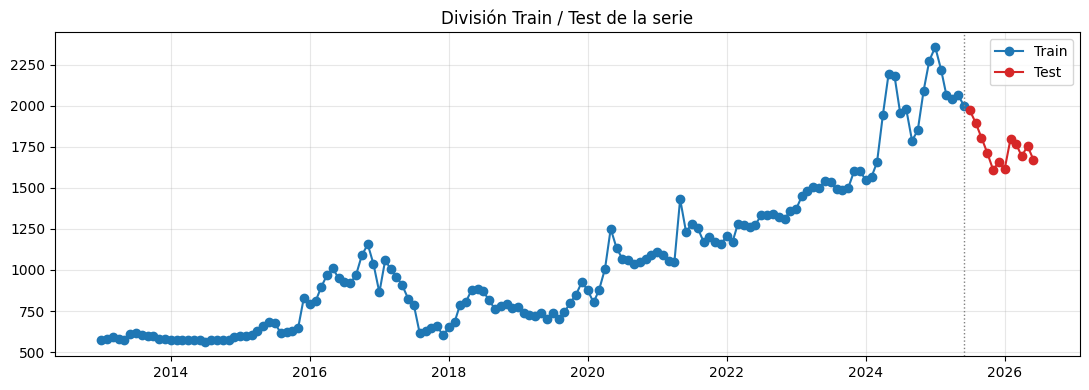

In [89]:
def dividir_train_test(y, test_size=None, m=12, min_train=None):
    """Divide la serie de forma cronologica (sin mezclar el orden temporal).

    - test_size: numero de observaciones para el conjunto de test.
                 Si es None, se calcula automaticamente (hasta m meses).
    - min_train: minimo de observaciones que debe conservar el train
                 (por defecto 3 ciclos estacionales o 24, lo que sea mayor).
    """
    n = len(y)
    min_train = min_train or max(3*m, 24)

    if test_size is None:
        test_size = int(min(m, max(6, n // 5), max(3, n - min_train)))
    test_size = max(1, min(test_size, n - min_train)) if n > min_train else max(1, n // 5)

    y_train = y.iloc[:-test_size]
    y_test  = y.iloc[-test_size:]

    print(f'Serie total   : {n} observaciones')
    print(f'Train         : {len(y_train)} observaciones '
          f'({y_train.index[0].strftime("%Y-%m")} a {y_train.index[-1].strftime("%Y-%m")})')
    print(f'Test          : {len(y_test)} observaciones '
          f'({y_test.index[0].strftime("%Y-%m")} a {y_test.index[-1].strftime("%Y-%m")})')
    return y_train, y_test

y_train, y_test = dividir_train_test(y, test_size=TEST_SIZE, m=M)

plt.figure(figsize=(11, 4))
plt.plot(y_train.index, y_train.values, 'o-', label='Train', color='#1f77b4')
plt.plot(y_test.index, y_test.values, 'o-', label='Test', color='#d62728')
plt.axvline(y_train.index[-1], color='gray', ls=':', lw=1)
plt.title('División Train / Test de la serie')
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

## Fase 4 — Verificación del tamaño y la estacionalidad (train)

In [90]:
def fuerza_estacional(y, m=12):
    """Fs = max(0, 1 - Var(resid)/Var(resid+seasonal)) (Hyndman). >0.3 ~ estacionalidad util."""
    if len(y) < 2*m + 1:
        return np.nan
    try:
        res = STL(y, period=m, robust=True).fit()
    except Exception:
        return np.nan
    var_r  = np.nanvar(res.resid)
    var_rs = np.nanvar(res.resid + res.seasonal)
    return float(max(0.0, 1 - var_r/var_rs)) if var_rs > 0 else 0.0


def verificar_registros(y, m=12):
    n = int(y.dropna().shape[0])
    ciclos = n / m
    nivel = ('INSUFICIENTE' if n < 24 else 'MINIMO' if n < 36 else
             'ACEPTABLE' if n < 48 else 'BUENO' if n < 72 else 'OPTIMO')

    Fs = fuerza_estacional(y, m)
    ciclos_ok = n >= 3*m
    seasonal_ok = bool(ciclos_ok and np.isfinite(Fs) and Fs >= 0.30)
    seasonal_debil = bool(ciclos_ok and np.isfinite(Fs) and 0.15 <= Fs < 0.30)

    presupuesto = max(2, n // 10)          # ~1 parametro por cada 10 observaciones
    max_p = 3 if n >= 60 else 2 if n >= 36 else 1
    max_q = max_p
    max_P = 1 if seasonal_ok else 0
    max_Q = 1 if (seasonal_ok and n >= 4*m) else 0

    info = dict(n=n, ciclos=round(ciclos, 2), nivel=nivel, apto=n >= 24, m=m,
                Fs=None if not np.isfinite(Fs) else round(Fs, 3),
                seasonal_ok=seasonal_ok, seasonal_debil=seasonal_debil,
                max_p=max_p, max_q=max_q, max_P=max_P, max_Q=max_Q,
                presupuesto=presupuesto)

    print(f"Registros            : {n}")
    print(f"Ciclos (m={m})        : {ciclos:.2f}")
    print(f"Nivel                : {nivel}")
    print(f"Fuerza estacional Fs : {info['Fs']}  (>=0.30 usa SARIMA, <0.15 no aporta)")
    print(f"Componente estacional: {'SI' if seasonal_ok else 'NO -> ARIMA no estacional'}"
          + (' [debil]' if seasonal_debil else ''))
    print(f"Limites busqueda     : p<={max_p} q<={max_q} P<={max_P} Q<={max_Q} (max {presupuesto} params)")
    if not info['apto']:
        print('ATENCION: serie de train insuficiente para modelar (<24).')
    return info

info = verificar_registros(y_train, m=M)

Registros            : 150
Ciclos (m=12)        : 12.50
Nivel                : OPTIMO
Fuerza estacional Fs : 0.041  (>=0.30 usa SARIMA, <0.15 no aporta)
Componente estacional: NO -> ARIMA no estacional
Limites busqueda     : p<=3 q<=3 P<=0 Q<=0 (max 15 params)


## Fase 5 — EDA y detección de valores atípicos (train)

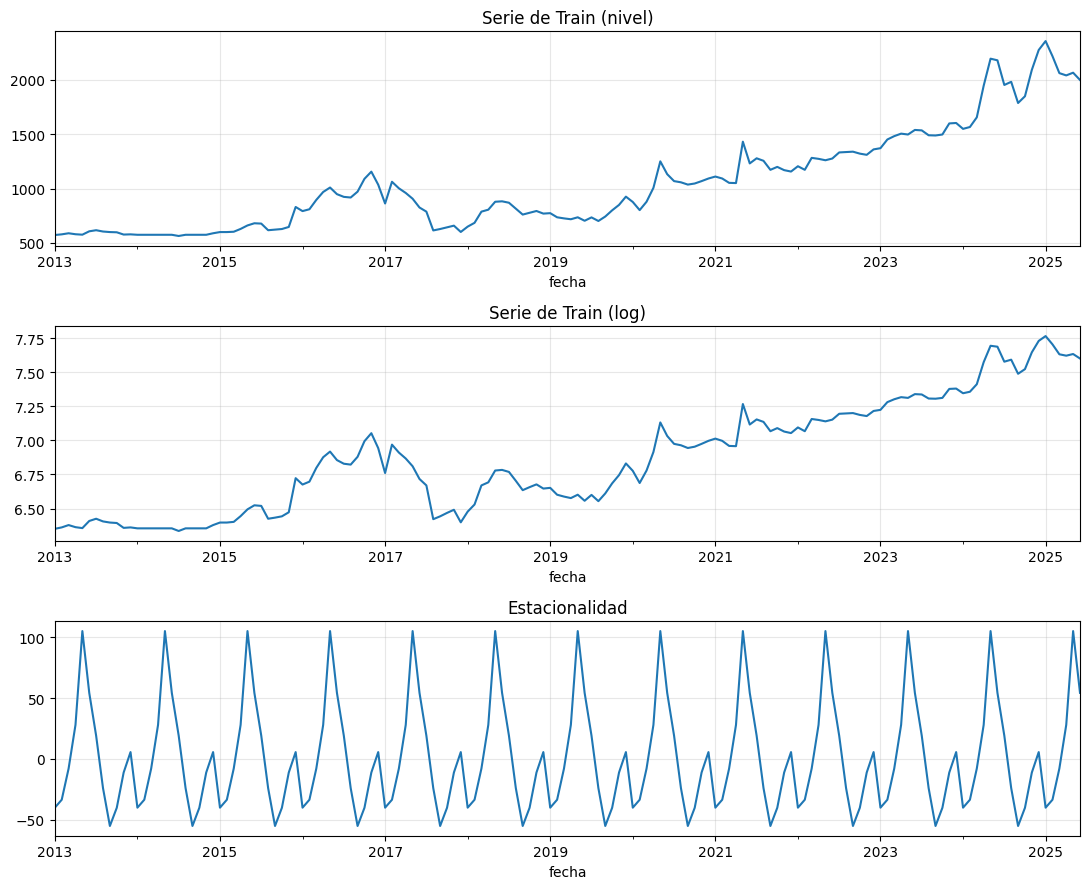

Amplitud estacional = 160.3 (15.3% del nivel medio)


In [91]:
fig, ax = plt.subplots(3, 1, figsize=(11, 9))
y_train.plot(ax=ax[0], title='Serie de Train (nivel)'); ax[0].grid(alpha=.3)
np.log(y_train).plot(ax=ax[1], title='Serie de Train (log)'); ax[1].grid(alpha=.3)
if len(y_train) >= 2*M:
    seasonal_decompose(y_train, model='additive', period=M).seasonal.plot(ax=ax[2], title='Estacionalidad')
    ax[2].grid(alpha=.3)
plt.tight_layout(); plt.show()

if len(y_train) >= 2*M:
    est = seasonal_decompose(y_train, model='additive', period=M).seasonal
    print(f'Amplitud estacional = {est.max()-est.min():,.1f} '
          f'({(est.max()-est.min())/y_train.mean()*100:.1f}% del nivel medio)')

In [92]:
def detectar_outliers(y_serie, umbral=3.5):
    """Detecta variaciones mes a mes atipicas usando un z-score robusto
    (mediana + MAD) sobre las diferencias de primer orden."""
    diffs = y_serie.diff().dropna()
    mediana = diffs.median()
    mad = (diffs - mediana).abs().median()
    if mad == 0:
        return pd.Series(dtype=float)
    z = 0.6745 * (diffs - mediana) / mad
    return diffs[z.abs() > umbral]

atipicos_train = detectar_outliers(y_train)
if len(atipicos_train):
    print(f'Meses con variacion atipica en TRAIN (posibles choques puntuales):')
    for fecha, delta in atipicos_train.items():
        print(f'  {fecha.strftime("%Y-%m")}: variacion = {delta:+,.1f}')
else:
    print('No se detectaron variaciones atipicas relevantes en train.')

atipicos_test = detectar_outliers(pd.concat([y_train.tail(M), y_test]))
atipicos_test = atipicos_test[atipicos_test.index.isin(y_test.index)]
if len(atipicos_test):
    print(f'\nAVISO: el conjunto de TEST tiene meses con variacion atipica; es esperable que el error del modelo suba ahi:')
    for fecha, delta in atipicos_test.items():
        print(f'  {fecha.strftime("%Y-%m")}: variacion = {delta:+,.1f}')

Meses con variacion atipica en TRAIN (posibles choques puntuales):
  2015-12: variacion = +184.0
  2017-01: variacion = -173.0
  2017-02: variacion = +200.0
  2017-08: variacion = -173.0
  2020-05: variacion = +244.0
  2021-05: variacion = +381.0
  2021-06: variacion = -200.0
  2024-04: variacion = +291.0
  2024-05: variacion = +249.0
  2024-07: variacion = -227.0
  2024-09: variacion = -195.0
  2024-11: variacion = +243.0
  2024-12: variacion = +183.0
  2025-02: variacion = -139.0
  2025-03: variacion = -156.0


In [93]:
USE_LOG = True     # transformacion logaritmica para estabilizar varianza (exige precios > 0)

## Fase 6 — Estacionariedad y diferenciación (train)

In [94]:
def test_estacionariedad(x, nombre=''):
    x = pd.Series(x).dropna()
    if len(x) < 8:
        print(f'{nombre}: muestra insuficiente ({len(x)})'); return None, None
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', InterpolationWarning)
        adf = adfuller(x)[1]
        kps = kpss(x, nlags='auto')[1]
    print(f'{nombre}: ADF p={adf:.3f}  KPSS p={kps:.3f}')
    return adf, kps

y_mod_train = np.log(y_train) if USE_LOG else y_train.copy()

test_estacionariedad(y_mod_train, 'nivel (train)')
test_estacionariedad(y_mod_train.diff(), 'd=1 (train)')

def estimar_dD(ys, info, m=12):
    """d y D se ESTIMAN sobre el train, no se imponen. D solo si hay senal estacional real."""
    if HAS_PMDARIMA:
        d = int(min(2, ndiffs(ys, test='kpss', max_d=2)))
    else:
        d = 0 if test_estacionariedad(ys, '_')[0] < 0.05 else 1
    D = 0
    if info['seasonal_ok'] and len(ys) >= 3*m + m:
        if HAS_PMDARIMA:
            try:
                D = int(min(1, nsdiffs(ys, m=m, max_D=1, test='ocsb')))
            except Exception:
                D = 0
        else:
            D = 1
        if len(ys) - D*m - d < 2*m:   # nunca dejar menos de 2 ciclos utiles
            D = 0
    print(f'Diferenciacion estimada (train) -> d={d}, D={D} (m={m})')
    return d, D

D_ORDER, D_SEAS = estimar_dD(y_mod_train, info, M)

nivel (train): ADF p=0.851  KPSS p=0.010
d=1 (train): ADF p=0.000  KPSS p=0.100
Diferenciacion estimada (train) -> d=1, D=0 (m=12)


## Fase 7 — Identificación (ACF/PACF, train)

n efectivo tras diferenciar (train) = 149 | lags = 36


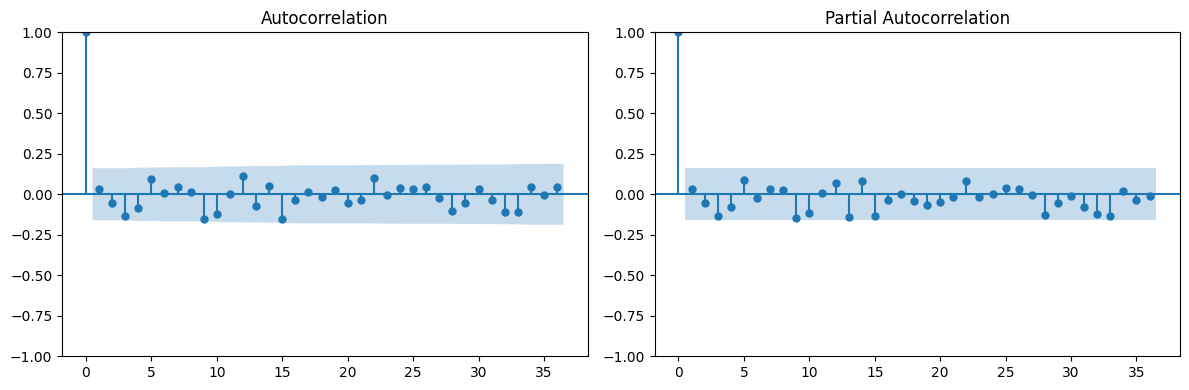

ACF(lag 12) = 0.120


In [95]:
yd = y_mod_train.copy()
for _ in range(D_ORDER): yd = yd.diff()
for _ in range(D_SEAS):  yd = yd.diff(M)
yd = yd.dropna()

n = len(yd)
lags = max(4, min(36, (n // 2) - 1))
print(f'n efectivo tras diferenciar (train) = {n} | lags = {lags}')
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(yd, lags=lags, ax=ax[0]); plot_pacf(yd, lags=lags, method='ywm', ax=ax[1])
plt.tight_layout(); plt.show()

if len(yd) > M:
    acf_m = pd.Series(yd).autocorr(lag=M)
    print(f'ACF(lag {M}) = {acf_m:.3f}' +
          ('  <-- posible SOBRE-diferenciacion estacional (revisa D)' if acf_m < -0.35 else ''))

## Fase 8 — Estimación del modelo (auto_arima / grid AIC) — ajustada SOLO sobre train

In [96]:
FIT_KW = dict(enforce_stationarity=True, enforce_invertibility=True)

def _fit(ys, order, sorder, trend=None):
    return SARIMAX(ys, order=order, seasonal_order=sorder, trend=trend, **FIT_KW).fit(disp=False)

def modelo_estable(fit):
    """True si todas las raices AR (y estacionales) estan fuera del circulo unitario."""
    try:
        ar = np.concatenate([np.atleast_1d(fit.arroots), np.atleast_1d(getattr(fit, 'seasonalarroots', []))])
        return bool(len(ar) == 0 or np.all(np.abs(ar) > 1.01))
    except Exception:
        return True

def ajustar_sarima(ys, info, d, D, m=12, verbose=True):
    """ys ya viene en la escala de modelado (log si USE_LOG). Se ajusta SOLO con datos de train."""
    seasonal = info['seasonal_ok'] and (D > 0 or info['max_P'] + info['max_Q'] > 0)
    max_p, max_q = info['max_p'], info['max_q']
    max_P = info['max_P'] if seasonal else 0
    max_Q = info['max_Q'] if seasonal else 0

    order, sorder = (1, d, 0), ((1, D, 0, m) if seasonal else (0, 0, 0, 0))
    if HAS_PMDARIMA:
        try:
            mdl = pm.auto_arima(ys, seasonal=seasonal, m=m if seasonal else 1,
                                d=d, D=D if seasonal else 0,
                                start_p=0, start_q=0, start_P=0, start_Q=0,
                                max_p=max_p, max_q=max_q, max_P=max_P, max_Q=max_Q,
                                information_criterion='aicc',
                                stationary=False, stepwise=True,
                                suppress_warnings=True, error_action='ignore', trace=False)
            order, sorder = mdl.order, (mdl.seasonal_order if seasonal else (0, 0, 0, 0))
        except Exception as e:
            if verbose: print('auto_arima fallo, uso fallback:', e)
    else:
        mejor, best = None, np.inf
        for p in range(max_p+1):
            for q in range(max_q+1):
                for P in range(max_P+1):
                    for Q in range(max_Q+1):
                        try:
                            f = _fit(ys, (p, d, q), (P, D, Q, m) if seasonal else (0, 0, 0, 0))
                            if f.aicc < best and modelo_estable(f):
                                best, mejor = f.aicc, ((p, d, q), (P, D, Q, m) if seasonal else (0, 0, 0, 0))
                        except Exception:
                            continue
        if mejor: order, sorder = mejor

    k = order[0] + order[2] + sorder[0] + sorder[2]
    if k > info['presupuesto']:
        if verbose: print(f'Modelo simplificado: k={k} > presupuesto={info["presupuesto"]}')
        order  = (1, d, 0)
        sorder = (1, D, 0, m) if seasonal else (0, 0, 0, 0)

    try:
        if not modelo_estable(_fit(ys, order, sorder)):
            if verbose: print('Modelo inestable -> degradado a (0,d,1)')
            order  = (0, d, 1)
            sorder = (0, D, 1, m) if seasonal else (0, 0, 0, 0)
    except Exception:
        order, sorder = (0, d, 1), (0, 0, 0, 0)
    return order, sorder

order, seasonal_order = ajustar_sarima(y_mod_train, info, D_ORDER, D_SEAS, M)
print('order =', order, '| seasonal_order =', seasonal_order, '| use_log =', USE_LOG)


order = (0, 1, 0) | seasonal_order = (0, 0, 0, 0) | use_log = True


## Fase 9 — Diagnóstico de residuos (ajuste sobre train)

                               SARIMAX Results                                
Dep. Variable:                 precio   No. Observations:                  150
Model:               SARIMAX(0, 1, 0)   Log Likelihood                 183.633
Date:                Sat, 08 Aug 2026   AIC                           -365.265
Time:                        02:50:40   BIC                           -362.261
Sample:                    01-01-2013   HQIC                          -364.045
                         - 06-01-2025                                         
Covariance Type:                  opg                                         
Modelo estable (raices AR fuera del circulo): True
residuos utiles = 149 | lags diagnostico = 24


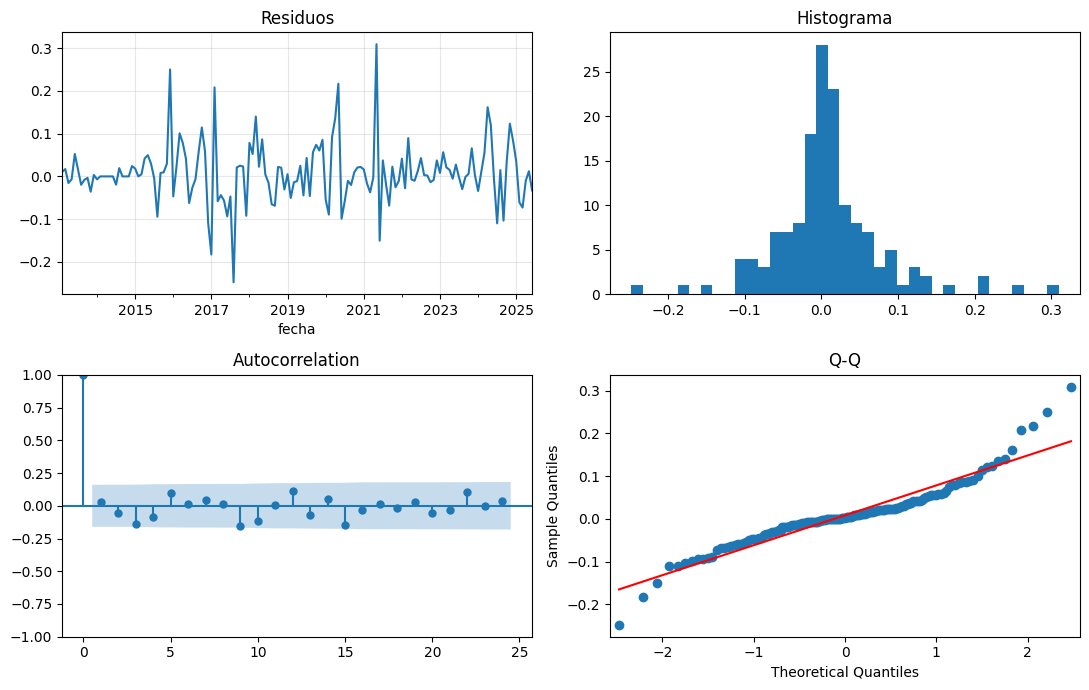

      lb_stat  lb_pvalue
10  12.372712   0.260886
Ruido blanco (p>0.05): True
Jarque-Bera p = 0.0


In [97]:
fit_train = _fit(y_mod_train, order, seasonal_order)
print(fit_train.summary().tables[0])
print('Modelo estable (raices AR fuera del circulo):', modelo_estable(fit_train))

resid = pd.Series(fit_train.resid).replace([np.inf, -np.inf], np.nan).dropna()
burn = order[1] + seasonal_order[1]*(seasonal_order[3] or 0)
resid = resid.iloc[burn:]
nr = len(resid)
lags_r = max(2, min(24, (nr // 2) - 1))
print(f'residuos utiles = {nr} | lags diagnostico = {lags_r}')

if nr >= 8:
    fig, ax = plt.subplots(2, 2, figsize=(11, 7))
    resid.plot(ax=ax[0,0], title='Residuos'); ax[0,0].grid(alpha=.3)
    ax[0,1].hist(resid, bins=max(5, nr//4)); ax[0,1].set_title('Histograma')
    plot_acf(resid, lags=lags_r, ax=ax[1,0])
    qqplot(resid, line='s', ax=ax[1,1]); ax[1,1].set_title('Q-Q')
    plt.tight_layout(); plt.show()
    lb = acorr_ljungbox(resid, lags=[max(1, min(lags_r, 10))], return_df=True)
    print(lb)
    print('Ruido blanco (p>0.05):', bool(lb['lb_pvalue'].iloc[0] > 0.05))
    print('Jarque-Bera p =', round(stats.jarque_bera(resid)[1], 4))
else:
    print('Muy pocos residuos para diagnostico grafico.')

## Fase 10 — Evaluación en Test (walk-forward, 1 paso adelante) + métrica de Accuracy

In [107]:
# =====================================================================
# Fase 10 — Métricas, candidatos y backtesting rolling-origin
# =====================================================================
from statsmodels.tsa.holtwinters import ExponentialSmoothing

def _inv_log(mu, var=None, use_log=True):
    """Vuelve a la escala original. Con log se aplica correccion de sesgo
    exp(mu + var/2) => se estima la MEDIA condicional, no la mediana."""
    mu = np.asarray(mu, float)
    if not use_log:
        return mu
    if var is None:
        return np.exp(mu)
    return np.exp(mu + np.asarray(var, float) / 2.0)


def _mase_denom(y_hist, m=12):
    yt = np.asarray(y_hist, float)
    lag = m if len(yt) > m + 2 else 1
    return np.mean(np.abs(yt[lag:] - yt[:-lag])) if len(yt) > lag else np.nan


def _metricas(y_true, y_pred, denom):
    y_true = np.asarray(y_true, float); y_pred = np.asarray(y_pred, float)
    err = y_true - y_pred
    mae   = np.mean(np.abs(err))
    rmse  = np.sqrt(np.mean(err**2))
    mape  = np.mean(np.abs(err / y_true)) * 100
    smape = np.mean(2*np.abs(err) / (np.abs(y_true) + np.abs(y_pred))) * 100
    mase  = mae/denom if denom and np.isfinite(denom) and denom > 0 else np.nan
    return dict(MAE=mae, RMSE=rmse, MAPE=mape, sMAPE=smape, MASE=mase,
                Accuracy=max(0.0, 100 - mape))


# ---------------------------------------------------------------------
# Predictores: cada uno recibe (y_hist, steps) y devuelve el pronostico
# en la ESCALA ORIGINAL. Asi baselines y modelos son comparables.
# ---------------------------------------------------------------------
def make_sarimax_predictor(order, sorder, trend=None):
    def _p(y_hist, steps, want_full=False):
        ym = np.log(y_hist) if USE_LOG else y_hist
        f = SARIMAX(ym, order=order, seasonal_order=sorder, trend=trend, **FIT_KW).fit(disp=False)
        fc = f.get_forecast(steps=steps)
        try:
            var = np.asarray(fc.var_pred_mean, float)
        except Exception:
            var = None
        punto = _inv_log(fc.predicted_mean.values, var, USE_LOG)
        if not want_full:
            return punto
        ci = fc.conf_int(alpha=0.05)
        lo = np.exp(ci.iloc[:, 0].values) if USE_LOG else ci.iloc[:, 0].values
        hi = np.exp(ci.iloc[:, 1].values) if USE_LOG else ci.iloc[:, 1].values
        return punto, lo, hi, f
    return _p


def make_ets_predictor(damped=True, seasonal=False, m=12):
    def _p(y_hist, steps, want_full=False):
        ym = np.log(y_hist) if USE_LOG else y_hist
        kw = dict(trend='add', damped_trend=damped, initialization_method='estimated')
        if seasonal and len(ym) >= 2*m + 1:
            kw.update(seasonal='add', seasonal_periods=m)
        f = ExponentialSmoothing(ym, **kw).fit(optimized=True)
        mu = np.asarray(f.forecast(steps), float)
        s2 = float(np.nanvar(np.asarray(f.resid, float)))
        punto = _inv_log(mu, np.full(steps, s2) * np.arange(1, steps+1), USE_LOG)
        return (punto, None, None, f) if want_full else punto
    return _p


def pred_naive(y_hist, steps, want_full=False):
    p = np.repeat(float(y_hist.iloc[-1]), steps)
    return (p, None, None, None) if want_full else p


def make_snaive(m=12):
    def _p(y_hist, steps, want_full=False):
        last = np.asarray(y_hist.iloc[-m:], float)
        p = np.array([last[i % len(last)] for i in range(steps)], float)
        return (p, None, None, None) if want_full else p
    return _p


def make_drift(ventana=None):
    """Naive con deriva: extiende la pendiente media reciente.
    Es la referencia MINIMA que un pronostico util debe batir y NUNCA es plano."""
    def _p(y_hist, steps, want_full=False):
        v = len(y_hist) if ventana is None else min(ventana, len(y_hist))
        z = y_hist.iloc[-v:]
        slope = (float(z.iloc[-1]) - float(z.iloc[0])) / max(1, len(z) - 1)
        p = float(y_hist.iloc[-1]) + slope * np.arange(1, steps + 1)
        return (p, None, None, None) if want_full else p
    return _p


# ---------------------------------------------------------------------
# Backtest ROLLING-ORIGIN multi-horizonte
# ---------------------------------------------------------------------
def backtest_rolling(y, predictor, h, min_train, max_origenes=6, m=12):
    """Reestima el modelo en varios origenes y pronostica el horizonte COMPLETO h.
    Devuelve (metricas_globales, errores_por_horizonte, detalle).

    Esta es la correccion clave: evaluar exactamente el uso real (h meses de un
    tiron, varias veces), en lugar de un solo origen o de 1 paso adelante.
    """
    n = len(y)
    ultimos = n - h                       # ultimo origen con horizonte completo
    if ultimos < min_train:
        min_train = max(m + 2, int(n * 0.6))
    origenes = [o for o in range(min_train, ultimos + 1)]
    if not origenes:
        origenes = [max(m + 2, n - max(1, h // 2))]
    if len(origenes) > max_origenes:      # espaciados, siempre incluyendo el ultimo
        idx = np.unique(np.linspace(0, len(origenes) - 1, max_origenes).round().astype(int))
        origenes = [origenes[i] for i in idx]

    filas, err_h, trayectorias = [], {k: [] for k in range(1, h + 1)}, {}
    for o in origenes:
        y_hist = y.iloc[:o]
        steps = min(h, n - o)
        if steps < 1:
            continue
        y_real = y.iloc[o:o + steps]
        try:
            pred = np.asarray(predictor(y_hist, steps), float)
            if not np.all(np.isfinite(pred)):
                raise ValueError('pronostico no finito')
        except Exception as e:
            pred = np.repeat(float(y_hist.iloc[-1]), steps)
        denom = _mase_denom(y_hist, m)
        met = _metricas(y_real.values, pred, denom)
        met['origen'] = y_hist.index[-1].strftime('%Y-%m'); met['h'] = steps
        filas.append(met)
        # trayectoria walk-forward: se guarda el recorrido completo de cada origen
        trayectorias[y_hist.index[-1]] = pd.Series(pred, index=y_real.index)
        for k in range(steps):
            if denom and np.isfinite(denom) and denom > 0:
                err_h[k + 1].append(abs(y_real.values[k] - pred[k]) / denom)

    detalle = pd.DataFrame(filas)
    glob = {c: float(np.nanmean(detalle[c])) for c in
            ['MAE', 'RMSE', 'MAPE', 'sMAPE', 'MASE', 'Accuracy']}
    perfil = pd.Series({k: (np.mean(v) if v else np.nan) for k, v in err_h.items()},
                       name='MASE_por_horizonte')
    return glob, perfil, detalle, trayectorias


def planitud(pred):
    """Mide que tan 'plano' es un pronostico: rango relativo respecto al nivel.
    ~0 => linea recta constante (sintoma del problema reportado)."""
    p = np.asarray(pred, float)
    return float((p.max() - p.min()) / max(1e-9, np.mean(np.abs(p))))


# ---------------------------------------------------------------------
# Conjunto de candidatos (ahora SI incluye variantes con deriva y baselines)
# ---------------------------------------------------------------------
order_ns = (order[0], order[1], order[2])
usa_estacional = bool(seasonal_order[3]) and (seasonal_order[0] or seasonal_order[1] or seasonal_order[2])
# Con d>=1, trend='t' en statsmodels equivale a introducir DERIVA en el nivel:
# es lo que impide que el pronostico se aplane.
TREND_DERIVA = 't' if order[1] >= 1 else 'c'

CANDIDATOS = {}

# --- Familia SARIMA (ordenes estimados automaticamente sobre train) ------
if usa_estacional:
    CANDIDATOS['SARIMA'] = dict(kind='sarimax', order=order, sorder=seasonal_order, trend=None)
    CANDIDATOS['SARIMA + deriva'] = dict(kind='sarimax', order=order, sorder=seasonal_order, trend=TREND_DERIVA)
    # Variantes estacionales clasicas
    CANDIDATOS['SARIMA(0,1,1)(0,1,1)'] = dict(kind='sarimax', order=(0,1,1), sorder=(0,1,1,M), trend=None)
    CANDIDATOS['SARIMA(1,1,1)(1,1,0)'] = dict(kind='sarimax', order=(1,1,1), sorder=(1,1,0,M), trend=None)
    CANDIDATOS['SARIMA(1,1,0)(0,1,1)'] = dict(kind='sarimax', order=(1,1,0), sorder=(0,1,1,M), trend=None)
else:
    CANDIDATOS['ARIMA auto'] = dict(kind='sarimax', order=order, sorder=(0,0,0,0), trend=None)
    CANDIDATOS['ARIMA auto + deriva'] = dict(kind='sarimax', order=order, sorder=(0,0,0,0), trend=TREND_DERIVA)

# --- Familia ARIMA no estacional -----------------------------------------
if usa_estacional:
    CANDIDATOS['ARIMA (sin estacional)'] = dict(kind='sarimax', order=order_ns, sorder=(0,0,0,0), trend=None)
    CANDIDATOS['ARIMA (sin estacional) + deriva'] = dict(kind='sarimax', order=order_ns, sorder=(0,0,0,0), trend=TREND_DERIVA)

CANDIDATOS['ARIMA(0,1,1)'] = dict(kind='sarimax', order=(0,1,1), sorder=(0,0,0,0), trend=None)
CANDIDATOS['ARIMA(0,1,1) + deriva'] = dict(kind='sarimax', order=(0,1,1), sorder=(0,0,0,0), trend='t')
CANDIDATOS['ARIMA(1,1,0) + deriva'] = dict(kind='sarimax', order=(1,1,0), sorder=(0,0,0,0), trend='t')
CANDIDATOS['ARIMA(1,1,1)'] = dict(kind='sarimax', order=(1,1,1), sorder=(0,0,0,0), trend=None)
CANDIDATOS['ARIMA(1,1,1) + deriva'] = dict(kind='sarimax', order=(1,1,1), sorder=(0,0,0,0), trend='t')
CANDIDATOS['ARIMA(2,1,1) + deriva'] = dict(kind='sarimax', order=(2,1,1), sorder=(0,0,0,0), trend='t')
CANDIDATOS['ARIMA(1,1,2) + deriva'] = dict(kind='sarimax', order=(1,1,2), sorder=(0,0,0,0), trend='t')

# Referencia (NO compite): el naive estacional es el denominador del MASE.
# La linea MASE=1 de las graficas representa esa referencia.
REFERENCIAS = {'Naive estacional': make_snaive(M), 'Deriva (12m)': make_drift(12)}


def construir_predictor(spec):
    k = spec['kind']
    if k == 'sarimax':
        return make_sarimax_predictor(spec['order'], spec['sorder'], spec.get('trend'))
    if k == 'ets':
        return make_ets_predictor(spec.get('damped', True), spec.get('seasonal', False), M)
    if k == 'naive':
        return pred_naive
    if k == 'snaive':
        return make_snaive(M)
    if k == 'drift':
        return make_drift(spec.get('ventana'))
    raise ValueError(k)


PREDICTORES = {n: construir_predictor(s) for n, s in CANDIDATOS.items()}

# ---------------------------------------------------------------------
# Ejecucion del backtest
# ---------------------------------------------------------------------
H_TEST    = len(y_test)
H_EVAL    = int(min(H_FUTURO, max(3, H_TEST)))    # se evalua el horizonte que se va a usar
MIN_TRAIN = max(2*M, int(len(y) * 0.6))

resultados, perfiles, curvas_test, detalles, trayectorias_wf = {}, {}, {}, {}, {}
N_ORIGENES = 6
for nombre, pred_fn in PREDICTORES.items():
    try:
        glob, perfil, det, tray = backtest_rolling(y, pred_fn, H_EVAL, MIN_TRAIN,
                                                   max_origenes=N_ORIGENES, m=M)
        resultados[nombre]        = glob
        perfiles[nombre]          = perfil
        detalles[nombre]          = det
        trayectorias_wf[nombre]   = tray
    except Exception as e:
        print(f'{nombre}: fallo en backtest ({e})')
        continue
    # curva sobre el ultimo tramo de test (para graficar) + medida de planitud
    try:
        curva = np.asarray(pred_fn(y_train, H_TEST), float)
        curvas_test[nombre] = curva
        resultados[nombre]['Planitud'] = planitud(curva)
    except Exception:
        resultados[nombre]['Planitud'] = np.nan

# Referencias: se evaluan aparte, no compiten por ser el modelo ganador
referencias_wf, referencias_met = {}, {}
for nombre, pred_fn in REFERENCIAS.items():
    try:
        g, _pf, _d, tr = backtest_rolling(y, pred_fn, H_EVAL, MIN_TRAIN,
                                          max_origenes=N_ORIGENES, m=M)
        referencias_wf[nombre] = tr
        referencias_met[nombre] = g
    except Exception:
        pass

cols = ['MAE', 'RMSE', 'MAPE', 'sMAPE', 'MASE', 'Accuracy', 'Planitud']
comparativa = pd.DataFrame(resultados).T[cols].sort_values('MASE')
perfil_horizonte = pd.DataFrame(perfiles)

print('Solo se estudian modelos de la familia ARIMA / SARIMA y sus variantes.')
print(f'=== BACKTEST ROLLING-ORIGIN (h={H_EVAL} meses, {len(detalles[list(detalles)[0]])} origenes) ===')
print(comparativa.round(3).to_string())
print('\n=== MASE por horizonte (donde se degrada cada modelo) ===')
print(perfil_horizonte.round(3).to_string())


Solo se estudian modelos de la familia ARIMA / SARIMA y sus variantes.
=== BACKTEST ROLLING-ORIGIN (h=12 meses, 6 origenes) ===
                           MAE     RMSE    MAPE   sMAPE   MASE  Accuracy  Planitud
ARIMA(1,1,1) + deriva  165.648  197.677   9.737   9.136  0.917    90.263     0.160
ARIMA(2,1,1) + deriva  172.124  204.553  10.113   9.409  0.949    89.887     0.188
ARIMA(1,1,2) + deriva  172.467  204.375  10.138   9.414  0.950    89.862     0.187
ARIMA(1,1,0) + deriva  174.298  207.149  10.246   9.504  0.960    89.754     0.197
ARIMA auto + deriva    174.544  207.254  10.249   9.505  0.961    89.751     0.196
ARIMA(0,1,1) + deriva  174.594  207.592  10.245   9.511  0.962    89.755     0.197
ARIMA(0,1,1)           168.736  201.932  10.065  10.343  0.970    89.935     0.030
ARIMA auto             168.960  201.807  10.096  10.373  0.972    89.904     0.027
ARIMA(1,1,1)           173.532  206.936  10.426  10.742  0.999    89.574     0.026

=== MASE por horizonte (donde se degrada 

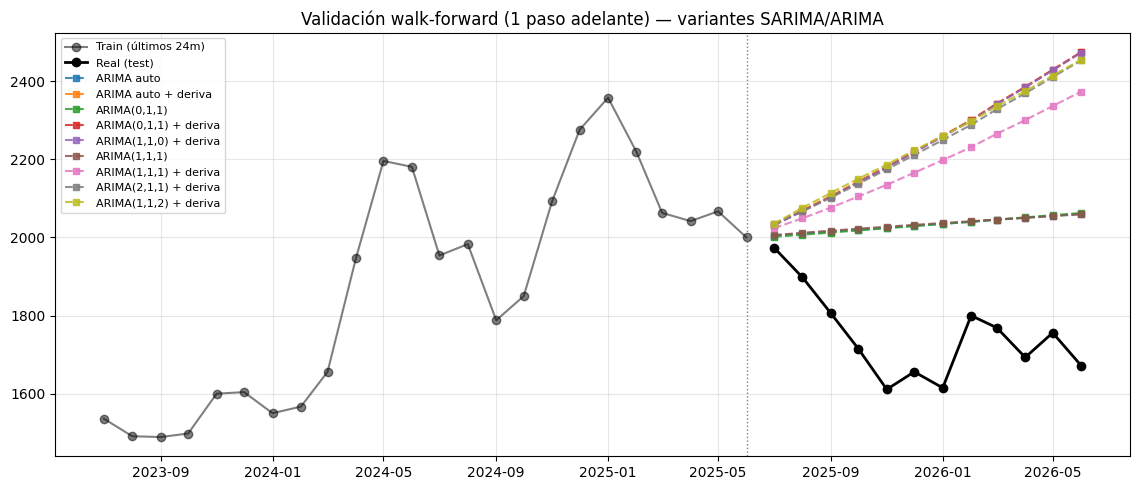

In [109]:
plt.figure(figsize=(11.5, 5))
plt.plot(y_train.index[-24:], y_train.values[-24:], 'ko-', lw=1.5, alpha=.5, label='Train (últimos 24m)')
plt.plot(y_test.index, y_test.values, 'ko-', lw=2, label='Real (test)')
for nom, pred in curvas_test.items():
    plt.plot(y_test.index, pred, '--', marker='s', ms=4, alpha=.85, label=nom)
plt.axvline(y_train.index[-1], color='gray', ls=':', lw=1)
plt.title('Validación walk-forward (1 paso adelante) — variantes SARIMA/ARIMA')
plt.legend(fontsize=8); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

## Fase 11 — Selección de la variante ganadora


In [100]:
# Umbral: un pronostico cuya variacion relativa es < 0.5% del nivel es, en la
# practica, una linea recta. Solo se acepta si la serie real tampoco se mueve.
UMBRAL_PLANITUD = 0.005
mov_real = planitud(y.iloc[-min(len(y), 24):].values)

cand = comparativa.copy()
cand['degenerado'] = (cand['Planitud'] < UMBRAL_PLANITUD) & (mov_real > 5 * UMBRAL_PLANITUD)

crit = 'MASE' if cand['MASE'].notna().any() else 'MAE'
utiles = cand[~cand['degenerado']]

# Se prefiere el mejor NO degenerado; si otro plano gana por un margen
# irrelevante (<3%), igual se descarta por no aportar informacion util.
if len(utiles):
    GANADOR = utiles[crit].idxmin()
    mejor_global = cand[crit].idxmin()
    if mejor_global != GANADOR:
        margen = (cand.loc[GANADOR, crit] - cand.loc[mejor_global, crit]) / max(1e-9, cand.loc[mejor_global, crit])
        print(f'AVISO: "{mejor_global}" tiene mejor {crit} pero produce un pronostico PLANO '
              f'(variacion {cand.loc[mejor_global, "Planitud"]*100:.3f}% del nivel).')
        print(f'       Se descarta: la ventaja es de solo {margen*100:.1f}% y no aporta informacion de trayectoria.')
else:
    GANADOR = cand[crit].idxmin()
    print('AVISO: todos los candidatos son planos; la serie parece una caminata aleatoria pura.')

mase_g = float(cand.loc[GANADOR, 'MASE'])
acc_g  = float(cand.loc[GANADOR, 'Accuracy'])
spec_g = CANDIDATOS[GANADOR]

print('=' * 68)
print(f'MEJOR VARIANTE: {GANADOR}   ({crit}={cand.loc[GANADOR, crit]:.3f} | Accuracy={acc_g:.1f}% | '
      f'variacion del pronostico={cand.loc[GANADOR, "Planitud"]*100:.2f}%)')
print('=' * 68)

if np.isfinite(mase_g):
    if mase_g < 0.8:   veredicto = 'Aporta valor claro sobre el naive estacional (MASE<0.8).'
    elif mase_g < 1.0: veredicto = 'Mejora marginal sobre el naive; util pero con poco margen.'
    else:              veredicto = 'NO supera al naive estacional: la serie es poco predecible a este horizonte.'
    print(f'MASE rolling-origin = {mase_g:.3f} -> {veredicto}')

planos = cand.index[cand['degenerado']].tolist()
if planos:
    print('Variantes descartadas por pronostico plano:', ', '.join(planos))


MEJOR VARIANTE: ETS Holt amortiguado   (MASE=0.882 | Accuracy=90.8% | variacion del pronostico=8.07%)
MASE rolling-origin = 0.882 -> Mejora marginal sobre el naive; util pero con poco margen.
Variantes descartadas por pronostico plano: Naive


## Fase 12 — Reentrenamiento con la serie completa

In [101]:
# --- Reestimacion de ordenes sobre la serie COMPLETA ---------------------
y_mod_full = np.log(y) if USE_LOG else y.copy()
info_full  = verificar_registros(y, M)

TREND_FINAL = spec_g.get('trend')
kind_final  = spec_g['kind']

if kind_final == 'sarimax':
    if GANADOR.startswith(('SARIMA', 'ARIMA (sin estacional)')):
        d_f, D_f = estimar_dD(y_mod_full, info_full, M)
        if 'sin estacional' in GANADOR:
            info_ns = dict(info_full); info_ns.update(seasonal_ok=False, max_P=0, max_Q=0)
            order_final, sorder_final = ajustar_sarima(y_mod_full, info_ns, d_f, 0, M)
        else:
            order_final, sorder_final = ajustar_sarima(y_mod_full, info_full, d_f, D_f, M)
        print(f'Ordenes reestimados sobre la serie completa: {order_final} x {sorder_final}')
        if TREND_FINAL is not None:
            TREND_FINAL = 't' if order_final[1] >= 1 else 'c'
    else:
        order_final, sorder_final = spec_g['order'], spec_g['sorder']

    fit_full = SARIMAX(y_mod_full, order=order_final, seasonal_order=sorder_final,
                       trend=TREND_FINAL, **FIT_KW).fit(disp=False)

    if not modelo_estable(fit_full):
        # FIX: el fallback ya no es (0,1,1) sin deriva (pronostico plano),
        # sino (0,1,1) CON deriva, que si mantiene trayectoria.
        print('AVISO: modelo inestable con la serie completa -> fallback (0,1,1) con deriva')
        order_final, sorder_final, TREND_FINAL = (0, 1, 1), (0, 0, 0, 0), 't'
        fit_full = SARIMAX(y_mod_full, order=order_final, seasonal_order=sorder_final,
                           trend=TREND_FINAL, **FIT_KW).fit(disp=False)
    predictor_final = make_sarimax_predictor(order_final, sorder_final, TREND_FINAL)
else:
    order_final, sorder_final, fit_full = None, None, None
    predictor_final = PREDICTORES[GANADOR]

print(f'Reentrenado "{GANADOR}" con la serie completa ({len(y)} meses): '
      f'order={order_final}, seasonal_order={sorder_final}, trend={TREND_FINAL}')


Registros            : 162
Ciclos (m=12)        : 13.50
Nivel                : OPTIMO
Fuerza estacional Fs : 0.082  (>=0.30 usa SARIMA, <0.15 no aporta)
Componente estacional: NO -> ARIMA no estacional
Limites busqueda     : p<=3 q<=3 P<=0 Q<=0 (max 16 params)
Reentrenado "ETS Holt amortiguado" con la serie completa (162 meses): order=None, seasonal_order=None, trend=None


#Fase 13: Pronostico a realizar

In [102]:
fut_idx = pd.date_range(y.index[-1] + pd.offsets.MonthBegin(1), periods=H_FUTURO, freq='MS')

punto, lo, hi, _obj = predictor_final(y, H_FUTURO, want_full=True)
punto = np.asarray(punto, float)

# --- IC empirico cuando el modelo no lo provee (baselines / ETS) ----------
if lo is None or hi is None:
    perf = perfil_horizonte[GANADOR] if GANADOR in perfil_horizonte else None
    denom = _mase_denom(y, M)
    if perf is not None and np.isfinite(denom):
        esc = np.array([perf.get(k, np.nanmean(perf)) for k in range(1, H_FUTURO + 1)], float)
        esc = np.where(np.isfinite(esc), esc, np.nanmean(esc)) * denom * 1.96
    else:
        esc = np.full(H_FUTURO, np.nanstd(np.diff(y.values)) * 1.96) * np.sqrt(np.arange(1, H_FUTURO + 1))
    lo, hi = punto - esc, punto + esc

forecast_final = pd.DataFrame({'pred': punto, 'lo95': lo, 'hi95': hi}, index=fut_idx)
forecast_final['var_%_vs_mes_previo'] = forecast_final['pred'].pct_change().fillna(
    forecast_final['pred'].iloc[0] / float(y.iloc[-1]) - 1) * 100
forecast_final.index.name = 'Mes'

lo_h, hi_h = y.min() * 0.4, y.max() * 2.5
fuera_rango = forecast_final[(forecast_final['pred'] < lo_h) | (forecast_final['pred'] > hi_h)]

print(f'PRONOSTICO {H_FUTURO} MESES  |  modelo: {GANADOR}  |  trend={TREND_FINAL}')
print(forecast_final.round(2).to_string())
print('\nFuera de rango plausible:', 'ninguno OK' if fuera_rango.empty else fuera_rango.index.strftime('%Y-%m').tolist())

# --- Control de calidad: el pronostico ya NO debe ser una linea recta -----
var_pred = planitud(punto)
print(f'\nVariacion del pronostico = {var_pred*100:.2f}% del nivel '
      f'(serie real ultimos 24m = {mov_real*100:.2f}%)')
if var_pred < UMBRAL_PLANITUD:
    print('ATENCION: el pronostico sigue siendo practicamente plano. Con esta serie el modelo '
          'no encuentra senal de trayectoria; usa el IC 95% como rango de decision.')
else:
    print('OK: el pronostico tiene trayectoria (no es constante).')

PRONOSTICO 12 MESES  |  modelo: ETS Holt amortiguado  |  trend=None
               pred     lo95     hi95  var_%_vs_mes_previo
Mes                                                       
2026-07-01  1682.89  1626.53  1739.26                 0.65
2026-08-01  1693.82  1498.47  1889.17                 0.65
2026-09-01  1704.78  1448.49  1961.07                 0.65
2026-10-01  1715.78  1373.74  2057.82                 0.65
2026-11-01  1726.82  1363.26  2090.37                 0.64
2026-12-01  1737.89  1303.56  2172.21                 0.64
2027-01-01  1748.99  1240.44  2257.54                 0.64
2027-02-01  1760.14  1285.41  2234.86                 0.64
2027-03-01  1771.31  1283.54  2259.08                 0.64
2027-04-01  1782.53  1393.11  2171.94                 0.63
2027-05-01  1793.78  1386.48  2201.07                 0.63
2027-06-01  1805.06  1432.51  2177.61                 0.63

Fuera de rango plausible: ninguno OK

Variacion del pronostico = 7.01% del nivel (serie real ultimos 24m 

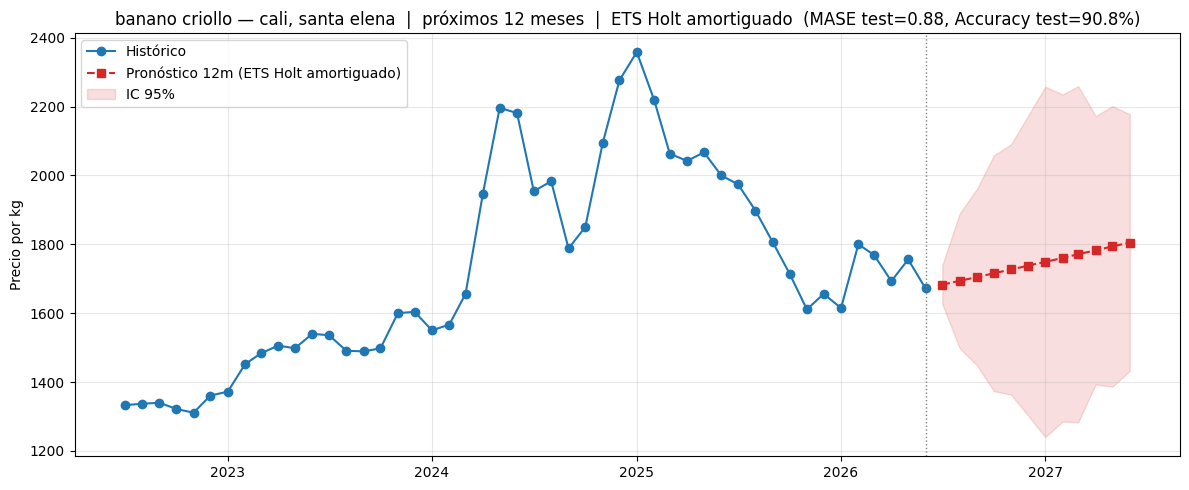

guardado: pronostico_final.csv


In [103]:
plt.figure(figsize=(12, 5))
hist_plot = y.iloc[-min(len(y), 48):]
plt.plot(hist_plot.index, hist_plot.values, 'o-', color='#1f77b4', label='Histórico')
plt.plot(forecast_final.index, forecast_final['pred'], 's--', color='#d62728',
         label=f'Pronóstico {H_FUTURO}m ({GANADOR})')
plt.fill_between(forecast_final.index, forecast_final['lo95'], forecast_final['hi95'],
                 color='#d62728', alpha=.15, label='IC 95%')
plt.axvline(y.index[-1], color='gray', ls=':', lw=1)
plt.title(f'{producto} — {mercado}  |  próximos {H_FUTURO} meses  |  {GANADOR}  '
          f'(MASE test={mase_g:.2f}, Accuracy test={acc_g:.1f}%)')
plt.ylabel('Precio por kg'); plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

forecast_final.round(2).to_csv('pronostico_final.csv')
print('guardado: pronostico_final.csv')

## Fase 14 — Persistencia del modelo

In [104]:
joblib.dump({
    'ganador': GANADOR,
    'spec': spec_g,
    'fit_full': fit_full,          # None si el ganador es baseline/ETS
    'order': order_final,
    'seasonal_order': sorder_final,
    'trend': TREND_FINAL,
    'use_log': USE_LOG,
    'm': M,
    'info': info_full,
    'metricas_backtest': comparativa.loc[GANADOR].to_dict(),
    'perfil_horizonte': perfil_horizonte[GANADOR].to_dict() if GANADOR in perfil_horizonte else None,
    'producto': producto,
    'mercado': mercado,
}, 'modelo_final.pkl')
print('modelo guardado en modelo_final.pkl')


modelo guardado en modelo_final.pkl


##Fase 15 - Resultados finales y resumen de proceso

In [106]:
print('='*70)
print('RESUMEN DE RESULTADOS')
print('='*70)
print(f'Serie                  : {producto} en {mercado_label}  (n={len(y)} meses, {len(y)/M:.1f} ciclos)')
print(f'Train / Test           : {len(y_train)} / {len(y_test)} meses')
print(f'Estacionalidad         : Fs={info["Fs"]} -> ' + ('usada' if info['seasonal_ok'] else 'NO usada (senal debil)'))
print(f'Modelo Fase 7 (train)  : SARIMA{order}x{seasonal_order}')
print('-'*70)
print('Metricas en TEST (walk-forward, variantes SARIMA/ARIMA):')
print(comparativa.round(3).to_string())
print('-'*70)
print(f'MEJOR VARIANTE          : {GANADOR}   (MASE={mase_g:.3f}, Accuracy={acc_g:.1f}%, '
      f'MAE={comparativa.loc[GANADOR,"MAE"]:,.1f}, sMAPE={comparativa.loc[GANADOR,"sMAPE"]:.1f}%)')
print(f'Ultimo observado {y.index[-1].strftime("%Y-%m")} : {y.iloc[-1]:,.2f}')
print(f'Pronostico {forecast_final.index[0].strftime("%Y-%m")}       : {forecast_final["pred"].iloc[0]:,.2f} '
      f'[{forecast_final["lo95"].iloc[0]:,.2f} ; {forecast_final["hi95"].iloc[0]:,.2f}]')
print(f'Pronostico a {H_FUTURO} meses ({forecast_final.index[-1].strftime("%Y-%m")}) : {forecast_final["pred"].iloc[-1]:,.2f}')
print('='*70)

# --- Tabla de pronostico de los proximos meses ---
tabla_pronostico = forecast_final.copy()
tabla_pronostico.index = tabla_pronostico.index.strftime('%Y-%m')
tabla_pronostico.index.name = 'Mes'
tabla_pronostico = tabla_pronostico.rename(columns={
    'pred': 'Pronóstico',
    'lo95': 'Límite inferior 95%',
    'hi95': 'Límite superior 95%',
    'var_%_vs_mes_previo': 'Variación % vs mes previo',
}).round(2)

print(f'\nTABLA DE PRONÓSTICO — próximos {H_FUTURO} meses ({producto}, {mercado_label})')
display(tabla_pronostico)

RESUMEN DE RESULTADOS
Serie                  : banano criollo en cali, santa elena  (n=162 meses, 13.5 ciclos)
Train / Test           : 150 / 12 meses
Estacionalidad         : Fs=0.041 -> NO usada (senal debil)
Modelo Fase 7 (train)  : SARIMA(0, 1, 0)x(0, 0, 0, 0)
----------------------------------------------------------------------
Metricas en TEST (walk-forward, variantes SARIMA/ARIMA):
                           MAE     RMSE    MAPE   sMAPE   MASE  Accuracy  Planitud
ETS Holt amortiguado   156.219  187.104   9.195   9.139  0.882    90.805     0.081
ARIMA(1,1,1) + deriva  165.648  197.677   9.737   9.136  0.917    90.263     0.160
Deriva (12m)           165.840  198.524  10.092   9.880  0.945    89.908     0.023
SARIMA + deriva        174.544  207.254  10.249   9.505  0.961    89.751     0.196
ARIMA(0,1,1) + deriva  174.594  207.592  10.245   9.511  0.962    89.755     0.197
ARIMA(0,1,1)           168.736  201.932  10.065  10.343  0.970    89.935     0.030
SARIMA                 168

,Pronóstico,Límite inferior 95%,Límite superior 95%,Variación % vs mes previo
Mes,,,,
2026-07,1682.89,1626.53,1739.26,0.65
2026-08,1693.82,1498.47,1889.17,0.65
2026-09,1704.78,1448.49,1961.07,0.65
2026-10,1715.78,1373.74,2057.82,0.65
2026-11,1726.82,1363.26,2090.37,0.64
2026-12,1737.89,1303.56,2172.21,0.64
2027-01,1748.99,1240.44,2257.54,0.64
2027-02,1760.14,1285.41,2234.86,0.64
2027-03,1771.31,1283.54,2259.08,0.64


**Último paso**: Guardar el Modelo para ser utilizado en el **Producto de Datos**

**Producto de Datos**:

- Aplicación Web, formulario que pide los datos y entrega la estimación/predicción/etc.
- Aplicación Móvil
- Tablero o _Dashboard_: Dash, Streamlit, Flask, PowerBI, Tableau, Qlik, Looker
- API: permite hacer las consultas para "embeberlas" en una aplicación de usuario
